<a href="https://colab.research.google.com/github/anu-v-nair/executive_program_in_advanced_ai_ml_iit_palakkad/blob/main/AI_Driven_Employee_Attrition_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Statement: AI-Driven Employee Attrition Prediction

A leading IT services company has observed an increase in employee resignations over
the last two years. The Human Resources (HR) department currently relies on manual
analysis and assumptions to identify employees who may leave the organization, which
is inefficient and often inaccurate.
The management wants to adopt a data-driven approach using Artificial Intelligence
and Machine Learning to proactively identify employees who are at risk of leaving the
company.

# Business Objective
Your task is to develop a supervised machine learning solution that predicts whether an
employee is likely to leave the organization based on employee-related factors such as:
• Salary  
• Overtime  
• Job satisfaction  
• Work-life balance  
• Promotions  
• Performance  
• Department  
• Experience  
• Absenteeism  
• Tenure  


The solution should help HR teams:
• Identify high-risk employees early  
• Understand the major reasons for attrition  
• Improve employee retention strategies  
• Reduce operational and hiring costs

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.model_selection import KFold, cross_val_score

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score

In [2]:
filepath = "/content/employee_attrition_dataset_10000.csv"
Data = pd.read_csv(filepath)
df = Data.copy()

# Basic Dataset Exploration

In [3]:
df.head()

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,Male,Single,Finance,Manager,5,7332,81,24,...,No,9,48,16,4,1,1,49,3,No
1,2,48,Female,Divorced,HR,Assistant,4,6069,55,18,...,Yes,9,57,10,4,1,1,25,1,No
2,3,34,Female,Married,Marketing,Manager,4,11485,65,6,...,Yes,3,55,1,1,4,3,21,1,Yes
3,4,27,Female,Divorced,HR,Manager,4,18707,28,12,...,No,9,53,2,3,4,1,46,2,No
4,5,40,Male,Married,HR,Analyst,1,16398,92,3,...,No,1,54,11,1,1,1,43,4,No


In [4]:
df.shape

(10000, 26)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Employee_ID                    10000 non-null  int64 
 1   Age                            10000 non-null  int64 
 2   Gender                         10000 non-null  object
 3   Marital_Status                 10000 non-null  object
 4   Department                     10000 non-null  object
 5   Job_Role                       10000 non-null  object
 6   Job_Level                      10000 non-null  int64 
 7   Monthly_Income                 10000 non-null  int64 
 8   Hourly_Rate                    10000 non-null  int64 
 9   Years_at_Company               10000 non-null  int64 
 10  Years_in_Current_Role          10000 non-null  int64 
 11  Years_Since_Last_Promotion     10000 non-null  int64 
 12  Work_Life_Balance              10000 non-null  int64 
 13  Jo

# Missing Value Analysis

In [6]:
df.isnull().sum()

,0
Employee_ID,0
Age,0
Gender,0
Marital_Status,0
Department,0
Job_Role,0
Job_Level,0
Monthly_Income,0
Hourly_Rate,0
Years_at_Company,0


In [7]:
df.isna().sum()

,0
Employee_ID,0
Age,0
Gender,0
Marital_Status,0
Department,0
Job_Role,0
Job_Level,0
Monthly_Income,0
Hourly_Rate,0
Years_at_Company,0


# Duplicate Checking

In [8]:
df.duplicated().sum()

np.int64(0)

# Statistical Summary

In [9]:
df.describe()

,Employee_ID,Age,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,Performance_Rating,Training_Hours_Last_Year,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,39.561800,2.990800,11436.716700,57.032300,14.936200,7.451300,4.471900,2.502400,3.038000,2.507700,49.588900,4.984400,44.473500,9.410200,2.493100,2.491400,2.505400,25.272000,2.516600
std,2886.89568,11.454986,1.410643,4926.528302,24.703261,8.431657,4.042903,2.891617,1.112348,1.414764,1.120833,28.801393,2.580043,8.611662,5.760335,1.120927,1.115101,1.116018,14.219474,1.113934
min,1.00000,20.000000,1.000000,3000.000000,15.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,30.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2500.75000,30.000000,2.000000,7182.500000,36.000000,8.000000,4.000000,2.000000,2.000000,2.000000,2.000000,25.000000,3.000000,37.000000,4.000000,1.000000,1.000000,2.000000,13.000000,2.000000
50%,5000.50000,40.000000,3.000000,11401.500000,57.000000,15.000000,7.000000,4.000000,2.000000,3.000000,3.000000,49.000000,5.000000,45.000000,9.000000,2.000000,2.000000,3.000000,25.000000,2.000000
75%,7500.25000,49.000000,4.000000,15679.500000,78.000000,22.000000,11.000000,7.000000,3.000000,4.000000,4.000000,75.000000,7.000000,52.000000,14.000000,4.000000,3.000000,3.000000,37.000000,4.000000
max,10000.00000,59.000000,5.000000,19999.000000,99.000000,29.000000,14.000000,9.000000,4.000000,5.000000,4.000000,99.000000,9.000000,59.000000,19.000000,4.000000,4.000000,4.000000,49.000000,4.000000


# Datatype Analysis

In [10]:
df.dtypes

,0
Employee_ID,int64
Age,int64
Gender,object
Marital_Status,object
Department,object
Job_Role,object
Job_Level,int64
Monthly_Income,int64
Hourly_Rate,int64
Years_at_Company,int64


In [11]:
df['Income_Band'] = pd.qcut(df['Monthly_Income'], 4, labels=False)

In [12]:
df['Experience_Level'] = pd.cut(df['Years_at_Company'],5,labels=False)

In [13]:
df.head()

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition,Income_Band,Experience_Level
0,1,58,Male,Single,Finance,Manager,5,7332,81,24,...,48,16,4,1,1,49,3,No,1,4
1,2,48,Female,Divorced,HR,Assistant,4,6069,55,18,...,57,10,4,1,1,25,1,No,0,3
2,3,34,Female,Married,Marketing,Manager,4,11485,65,6,...,55,1,1,4,3,21,1,Yes,2,0
3,4,27,Female,Divorced,HR,Manager,4,18707,28,12,...,53,2,3,4,1,46,2,No,3,1
4,5,40,Male,Married,HR,Analyst,1,16398,92,3,...,54,11,1,1,1,43,4,No,3,0


# 3. Exploratory Data Analysis (EDA)

# Attrition Distribution

/tmp/ipykernel_73291/1714326748.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Attrition', data=df, palette='gist_heat')


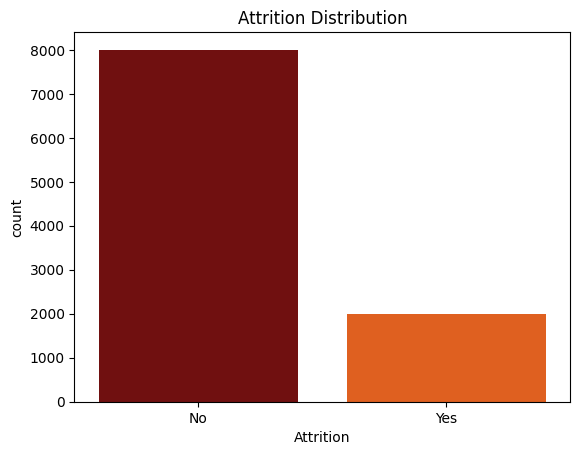

In [14]:
sns.countplot(x='Attrition', data=df, palette='gist_heat')
plt.title('Attrition Distribution')
plt.show()

The attrition distribution shows that approximately:

* 80% of employees remained
* 20% of employees left

While the majority of employees are retained, a 20% attrition rate is still significant enough to affect:

* Recruitment and onboarding costs
* Team productivity
* Employee morale
* Organizational continuity

**Business Insight**

The organization should proactively monitor retention trends to prevent turnover from increasing over time.

Text(0.5, 1.0, 'Attrition by Department')

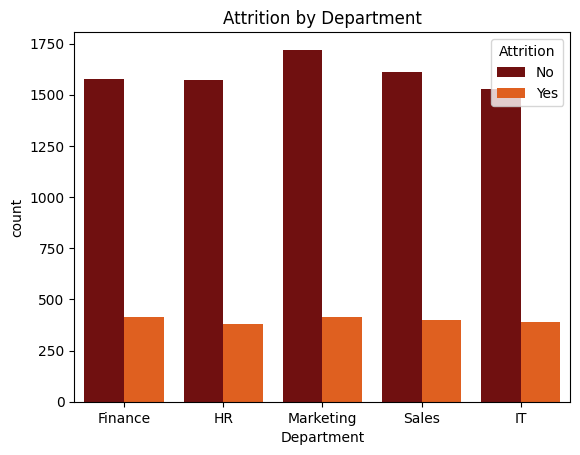

In [15]:
sns.countplot(x='Department', hue='Attrition', data=df, palette='gist_heat')
plt.title("Attrition by Department")

The department-wise analysis indicates that attrition levels are relatively similar across:

* Finance
* HR
* Marketing
* Sales
* IT

Although Marketing appears to have slightly higher employee counts and marginally higher attrition, the differences are not substantial.

**Business Insight**

Attrition does not appear to be concentrated in a single department. This suggests that organization-wide factors such as employee engagement, career development, leadership, or workplace culture may be influencing turnover more than department-specific issues.

**Recommendation**

Focus on enterprise-wide retention initiatives rather than targeting only one functional area.

# Attrition by Overtime

Text(0.5, 1.0, 'Attrition by Overtime')

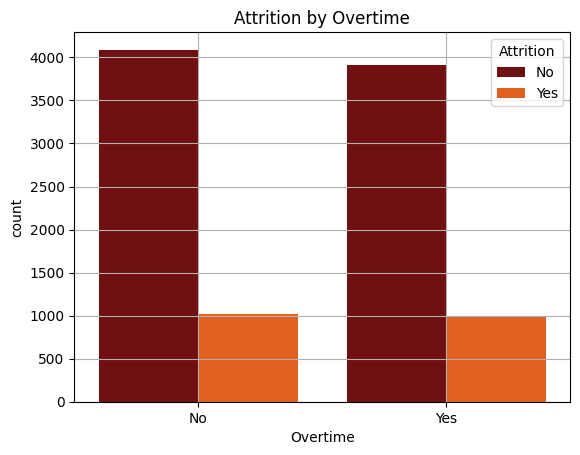

In [16]:
sns.countplot(x='Overtime', hue='Attrition', data=df, palette='gist_heat')
plt.grid(True)
plt.title("Attrition by Overtime")

The overtime comparison shows similar attrition patterns among employees who work overtime and those who do not.

# Attrition by Monthly Income

Text(0.5, 1.0, 'Attrition by Monthly Income')

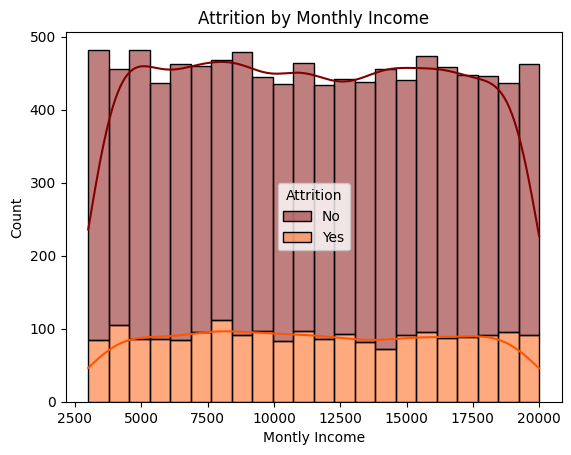

In [17]:
sns.histplot(x='Monthly_Income', hue='Attrition', data=df, kde=True, multiple = 'stack',palette='gist_heat')
plt.xlabel("Montly Income")
plt.title("Attrition by Monthly Income")

The distribution shows that employee attrition occurs across nearly all income levels, with no major concentration in a specific salary range.

# Attrition by Job Satisfaction

Text(0.5, 0, 'Job Satisfaction')

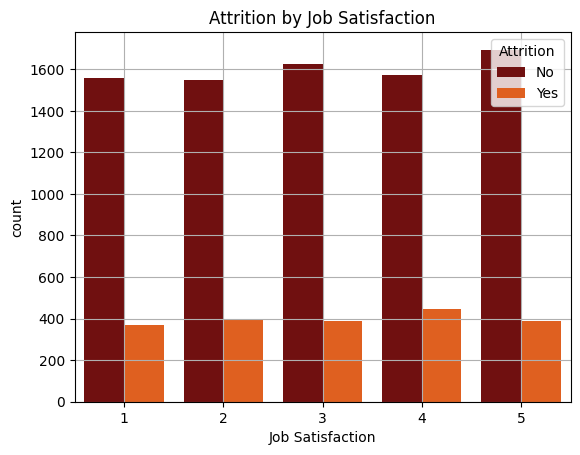

In [18]:
sns.countplot(x='Job_Satisfaction',hue='Attrition',data=df,palette = "gist_heat")
plt.grid(True)
plt.title("Attrition by Job Satisfaction")
plt.xlabel("Job Satisfaction")

The analysis shows that attrition is relatively consistent across different job satisfaction levels, with no major differences between employees who stayed and those who left.

**Business Insight**

Job satisfaction alone may not be a strong predictor of employee attrition in this dataset. Employees with both low and high satisfaction levels are leaving the organization.

This suggests that attrition is likely influenced by multiple factors, such as:

* Career advancement opportunities
* Compensation and benefits
* Leadership and management quality
* Work-life balance
* Employee engagement

**Recommendation**

The organization should evaluate job satisfaction alongside other workforce metrics to better understand employee turnover patterns. A broader retention strategy focused on employee experience, growth opportunities, and organizational support may be more effective in reducing attrition.

# Correlation Heatmap

In [19]:
num_cols = [col for col in df.columns if df[col].dtypes != "O"]

Text(0.5, 1.0, 'Correlation Heatmap')

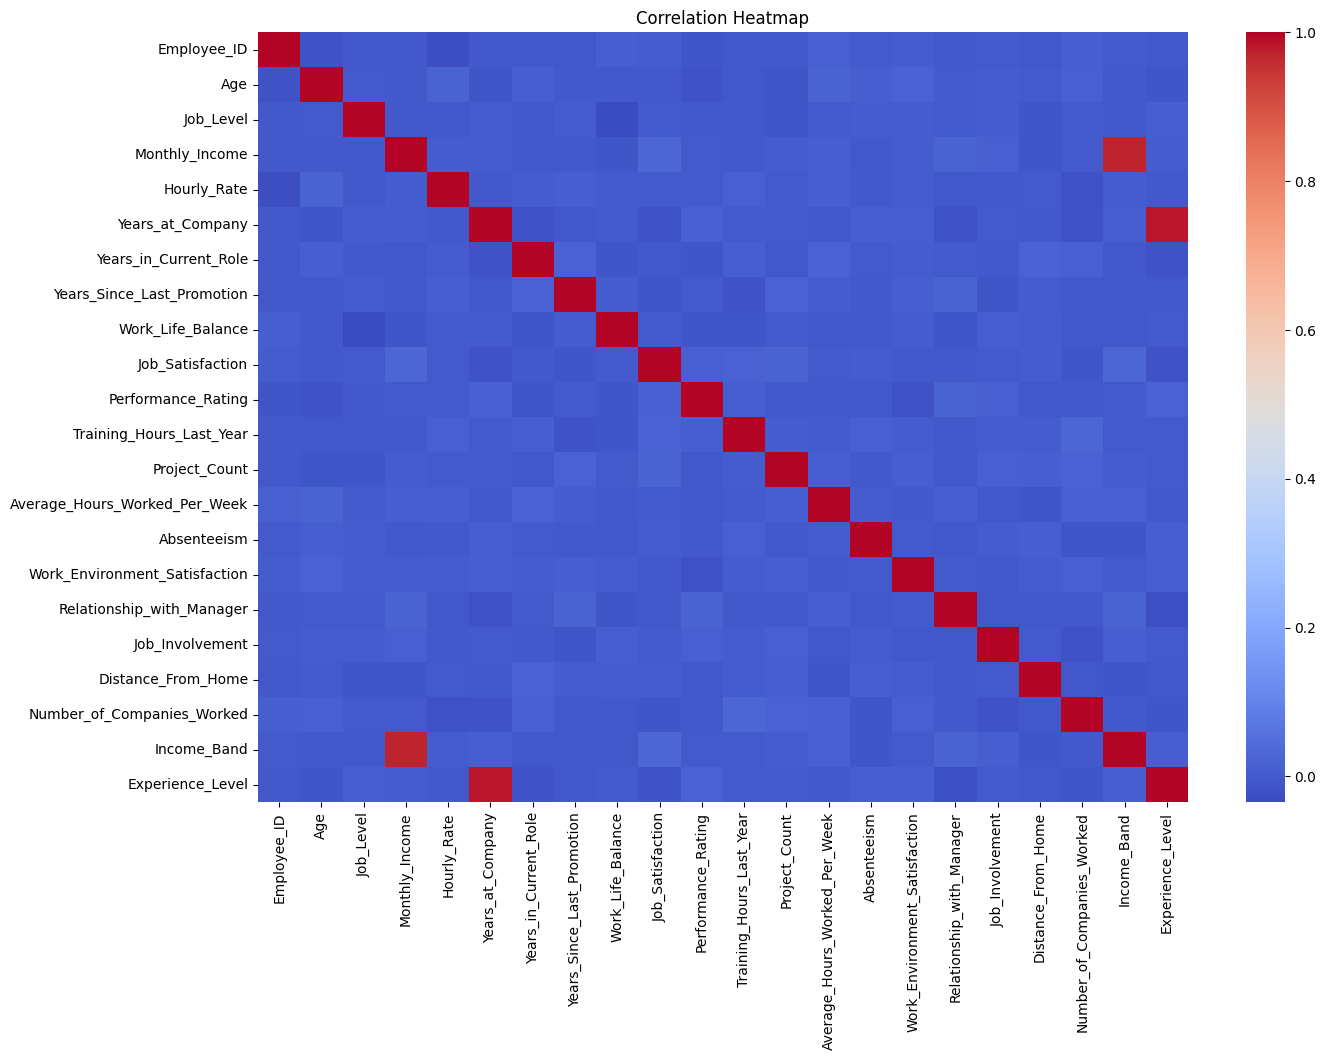

In [20]:
plt.figure(figsize=(15,10))
correlation = df[num_cols].corr()
sns.heatmap(correlation, cmap='coolwarm')
plt.title("Correlation Heatmap")

# Outlier Detection

/tmp/ipykernel_73291/579101236.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[column],palette = "gist_heat")


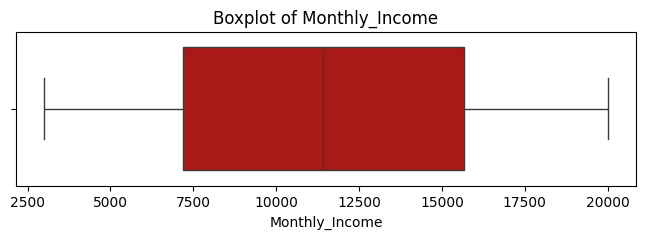

/tmp/ipykernel_73291/579101236.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[column],palette = "gist_heat")


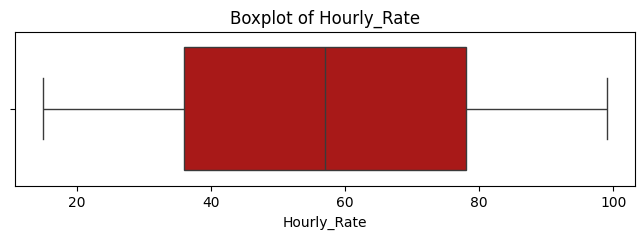

/tmp/ipykernel_73291/579101236.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[column],palette = "gist_heat")


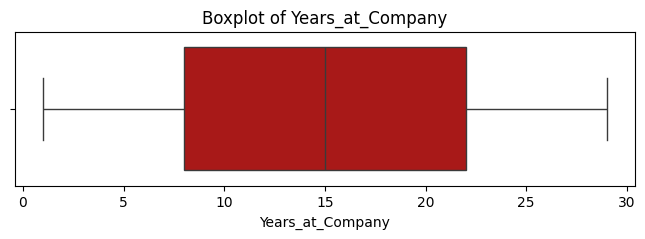

/tmp/ipykernel_73291/579101236.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[column],palette = "gist_heat")


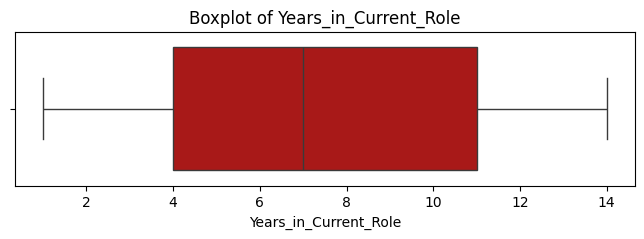

/tmp/ipykernel_73291/579101236.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[column],palette = "gist_heat")


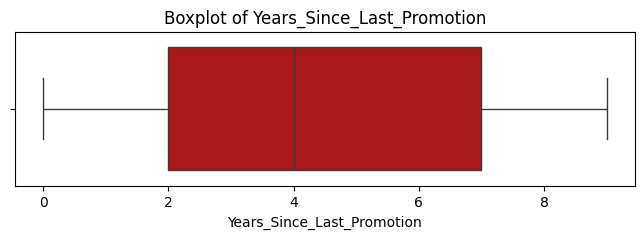

/tmp/ipykernel_73291/579101236.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[column],palette = "gist_heat")


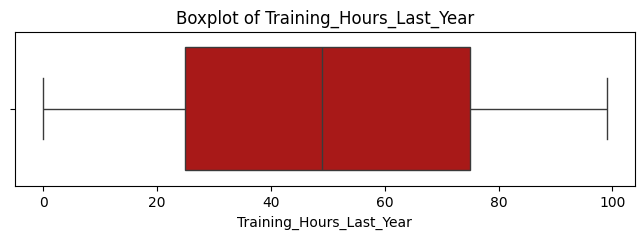

/tmp/ipykernel_73291/579101236.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[column],palette = "gist_heat")


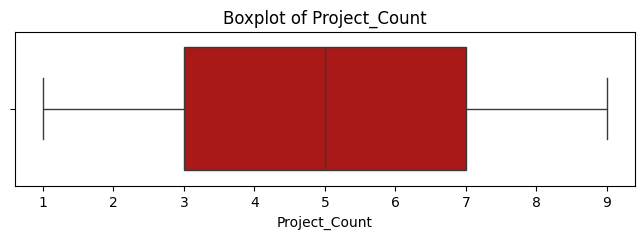

/tmp/ipykernel_73291/579101236.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[column],palette = "gist_heat")


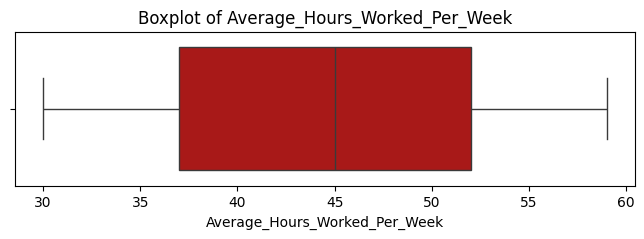

/tmp/ipykernel_73291/579101236.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[column],palette = "gist_heat")


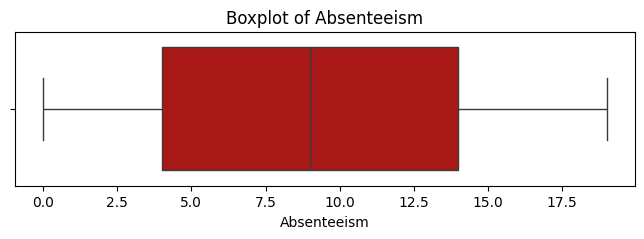

/tmp/ipykernel_73291/579101236.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[column],palette = "gist_heat")


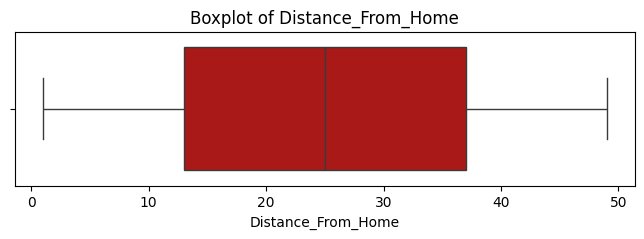

/tmp/ipykernel_73291/579101236.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[column],palette = "gist_heat")


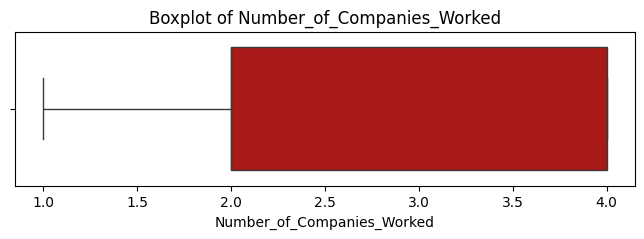

In [21]:
outlier_check = ['Monthly_Income',
 'Hourly_Rate','Years_at_Company',
 'Years_in_Current_Role',
 'Years_Since_Last_Promotion','Training_Hours_Last_Year','Project_Count',
 'Average_Hours_Worked_Per_Week','Absenteeism','Distance_From_Home',
 'Number_of_Companies_Worked']
for column in outlier_check:
  plt.figure(figsize=(8, 2))
  sns.boxplot(x=df[column],palette = "gist_heat")
  plt.title(f'Boxplot of {column}')
  plt.xlabel(column)
  plt.show()

# Variance Inflation Factor

In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

feature_df = df[num_cols]
vif_data = pd.DataFrame()

vif_data["Feature"] = feature_df.columns

vif_data["VIF"] = [
    variance_inflation_factor(feature_df.values, i)
    for i in range(len(feature_df.columns))
]
vif_data

,Feature,VIF
0,Employee_ID,3.900666
1,Age,11.844006
2,Job_Level,5.277146
3,Monthly_Income,89.271581
4,Hourly_Rate,6.090141
5,Years_at_Company,102.813033
6,Years_in_Current_Role,4.294060
7,Years_Since_Last_Promotion,3.337991
8,Work_Life_Balance,5.771845
9,Job_Satisfaction,5.438241


The Variance Inflation Factor (VIF) results indicate that several variables have high multicollinearity, meaning some features are strongly correlated with one another and may negatively affect model stability and interpretability.

In [23]:
pd.crosstab(
    [df['Department'], df['Overtime']],
    df['Attrition'],
    normalize='index'
)

Attrition                  No       Yes
Department Overtime                    
Finance    No        0.793855  0.206145
           Yes       0.788991  0.211009
HR         No        0.802010  0.197990
           Yes       0.807933  0.192067
IT         No        0.796488  0.203512
           Yes       0.796414  0.203586
Marketing  No        0.814509  0.185491
           Yes       0.797893  0.202107
Sales      No        0.798464  0.201536
           Yes       0.805383  0.194617

- Attrition rates are generally clustered around 18%–21% across departments.
- Overtime does not consistently increase attrition across all departments.
- Marketing shows the clearest overtime-related increase in attrition.
- IT demonstrates virtually no attrition difference regardless of overtime status

**Business Interpretation**

- Overtime alone is likely not the dominant factor driving employee exits organization-wide.
- Department-specific dynamics matter more:
- - Marketing employees may experience burnout or workload pressure when overtime increases.
- - IT employees may already expect flexible or extended work patterns as part of their role norms.
- - HR and Sales show slight decreases in attrition with overtime, potentially reflecting higher engagement or incentive-linked work.

**Strategic Recommendation**
- Use a department-specific retention strategy rather than a uniform overtime policy.
- Prioritize:
- - Burnout monitoring in Marketing
- - Workload balance reviews
- - Department-level engagement surveys
- - Managerial support assessments

In [24]:
df.groupby('Attrition')[
    ['Monthly_Income',
     'Job_Satisfaction',
     'Average_Hours_Worked_Per_Week']
].mean()

,Monthly_Income,Job_Satisfaction,Average_Hours_Worked_Per_Week
Attrition,,,
No,11436.385605,3.036486,44.484068
Yes,11438.043565,3.044066,44.431147


Employees who left and employees who stayed have:

- Nearly identical monthly income
- Nearly identical job satisfaction scores
- Nearly identical average working hours

**Business Interpretation**

- Traditional indicators often associated with turnover are not differentiating attrition behavior in this dataset.
- This suggests attrition may be influenced by factors not captured here, such as:
- - Career advancement opportunities
- - Organizational culture
- - Leadership quality
- - Employee recognition
- - Team dynamics
- - External labor market opportunities

**Strategic Recommendation**
The company should expand attrition analysis to include:
- Employee engagement metrics
- Promotion history
- Manager feedback
- Training participation
- Internal mobility
- Exit interview themes

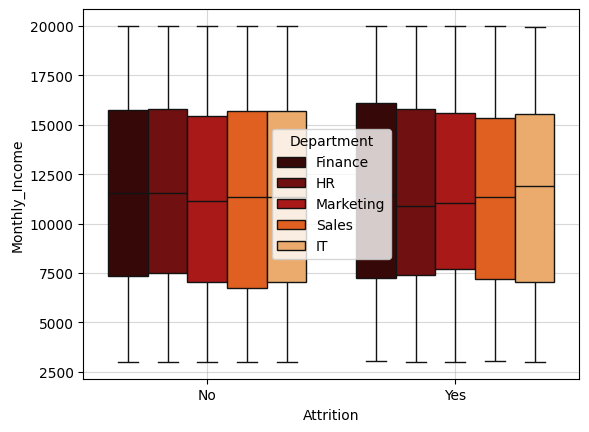

In [25]:
sns.boxplot(
    x='Attrition',
    y='Monthly_Income',
    hue='Department',
    data=df,
    palette = "gist_heat"
)
plt.grid(True,alpha=0.5)

- Salary distributions are very similar for employees who stayed and those who left across all departments.
- Median monthly income remains consistent regardless of attrition status.
- Wide salary ranges indicate a mix of junior, mid-level, and senior employees within each department.

**Business Interpretation**
- Compensation does not appear to be a major driver of attrition.
- Other factors such as career growth, leadership, work culture, and employee engagement may have a stronger influence on turnover.
- IT and Finance show broader salary variation, likely due to diverse role specializations and experience levels.

**Recommendations**
- Focus retention efforts on career development, employee engagement, and managerial support rather than salary alone.
- Conduct employee surveys and exit interviews to identify non-financial reasons for attrition.

# 4. Data Preprocessing

# Dropping Unnecessary Columns

In [26]:
df.drop('Employee_ID', axis=1, inplace=True)

# Encoding Target Variable

In [27]:
df['Attrition'] = df['Attrition'].map({'No':0, 'Yes':1})

# Separating Features and Target

In [28]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

# One Hot Encoding for Categorical Variables

In [29]:
cat_cols = X.select_dtypes(include='object').columns
cat_cols

Index(['Gender', 'Marital_Status', 'Department', 'Job_Role', 'Overtime'], dtype='object')

In [30]:
num_cols = X.select_dtypes(exclude='object').columns
num_cols

Index(['Age', 'Job_Level', 'Monthly_Income', 'Hourly_Rate', 'Years_at_Company',
       'Years_in_Current_Role', 'Years_Since_Last_Promotion',
       'Work_Life_Balance', 'Job_Satisfaction', 'Performance_Rating',
       'Training_Hours_Last_Year', 'Project_Count',
       'Average_Hours_Worked_Per_Week', 'Absenteeism',
       'Work_Environment_Satisfaction', 'Relationship_with_Manager',
       'Job_Involvement', 'Distance_From_Home', 'Number_of_Companies_Worked',
       'Income_Band', 'Experience_Level'],
      dtype='object')

In [31]:
ohe = OneHotEncoder(drop="first",sparse_output=False,handle_unknown='ignore')

In [32]:
encoded_cols = ohe.fit_transform(X[cat_cols])

In [33]:
encoded_cols

array([[1., 0., 1., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 1., 1.],
       ...,
       [1., 0., 0., ..., 0., 1., 1.],
       [0., 0., 1., ..., 0., 1., 1.],
       [0., 0., 0., ..., 1., 0., 1.]])

In [34]:
encoded_df = pd.DataFrame(encoded_cols, columns=ohe.get_feature_names_out(cat_cols),index=X.index)

In [35]:
encoded_df

,Gender_Male,Marital_Status_Married,Marital_Status_Single,Department_HR,Department_IT,Department_Marketing,Department_Sales,Job_Role_Assistant,Job_Role_Executive,Job_Role_Manager,Overtime_Yes
0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
9995,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
9996,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
9997,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
9998,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0


In [36]:
X=pd.concat([X[num_cols], encoded_df], axis=1)

In [37]:
X

,Age,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,Performance_Rating,...,Marital_Status_Married,Marital_Status_Single,Department_HR,Department_IT,Department_Marketing,Department_Sales,Job_Role_Assistant,Job_Role_Executive,Job_Role_Manager,Overtime_Yes
0,58,5,7332,81,24,12,3,1,3,2,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,48,4,6069,55,18,7,5,1,2,2,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,34,4,11485,65,6,4,3,4,5,1,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
3,27,4,18707,28,12,9,1,1,1,2,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,40,1,16398,92,3,9,1,3,4,3,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,22,5,4276,27,17,5,1,3,5,3,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
9996,35,3,10327,60,19,11,6,2,1,4,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
9997,23,3,12592,68,10,11,4,4,2,4,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
9998,42,3,9287,26,18,7,8,1,5,1,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0


In [38]:
df.head(2)

,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,...,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition,Income_Band,Experience_Level
0,58,Male,Single,Finance,Manager,5,7332,81,24,12,...,48,16,4,1,1,49,3,0,1,4
1,48,Female,Divorced,HR,Assistant,4,6069,55,18,7,...,57,10,4,1,1,25,1,0,0,3


In [39]:
X

,Age,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,Performance_Rating,...,Marital_Status_Married,Marital_Status_Single,Department_HR,Department_IT,Department_Marketing,Department_Sales,Job_Role_Assistant,Job_Role_Executive,Job_Role_Manager,Overtime_Yes
0,58,5,7332,81,24,12,3,1,3,2,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,48,4,6069,55,18,7,5,1,2,2,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,34,4,11485,65,6,4,3,4,5,1,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
3,27,4,18707,28,12,9,1,1,1,2,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,40,1,16398,92,3,9,1,3,4,3,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,22,5,4276,27,17,5,1,3,5,3,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
9996,35,3,10327,60,19,11,6,2,1,4,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
9997,23,3,12592,68,10,11,4,4,2,4,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
9998,42,3,9287,26,18,7,8,1,5,1,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0


In [40]:
y

,Attrition
0,0
1,0
2,1
3,0
4,0
...,...
9995,0
9996,0
9997,1
9998,0


# Train Test Split

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=17,
    stratify=y
)

# Feature Scaling

In [42]:
num_cols

Index(['Age', 'Job_Level', 'Monthly_Income', 'Hourly_Rate', 'Years_at_Company',
       'Years_in_Current_Role', 'Years_Since_Last_Promotion',
       'Work_Life_Balance', 'Job_Satisfaction', 'Performance_Rating',
       'Training_Hours_Last_Year', 'Project_Count',
       'Average_Hours_Worked_Per_Week', 'Absenteeism',
       'Work_Environment_Satisfaction', 'Relationship_with_Manager',
       'Job_Involvement', 'Distance_From_Home', 'Number_of_Companies_Worked',
       'Income_Band', 'Experience_Level'],
      dtype='object')

In [43]:
scaling_cols = num_cols

In [44]:
scaler = StandardScaler()

X_train[scaling_cols] = scaler.fit_transform(X_train[scaling_cols])
X_test[scaling_cols] = scaler.transform(X_test[scaling_cols])

In [45]:
smote = SMOTE(random_state=17)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

# Feature Selection

In [46]:
selector = SelectKBest(score_func=f_classif, k=15)

X_train_selected = selector.fit_transform(X_train_smote, y_train_smote)

X_test_selected = selector.transform(X_test)

In [62]:
selected_features = X.columns[selector.get_support()]
selected_features

Index(['Age', 'Job_Level', 'Years_in_Current_Role', 'Work_Life_Balance',
       'Performance_Rating', 'Training_Hours_Last_Year',
       'Average_Hours_Worked_Per_Week', 'Work_Environment_Satisfaction',
       'Job_Involvement', 'Distance_From_Home', 'Gender_Male',
       'Marital_Status_Married', 'Department_Sales', 'Job_Role_Assistant',
       'Job_Role_Manager'],
      dtype='object')

# 5.Model Building

# Logistic Regression

In [47]:
k_fold = KFold(n_splits=5, shuffle = True)

In [48]:
log_model = LogisticRegression(
    class_weight='balanced',
    random_state=17
)

log_cv_scores = cross_val_score(log_model, X_train_selected, y_train_smote, cv=k_fold, scoring='f1')
log_cv_mean_score = log_cv_scores.mean()
log_std_deviation = log_cv_scores.std()

log_model.fit(X_train_selected, y_train_smote)

y_pred_log = log_model.predict(X_test_selected)
y_prob_log = log_model.predict_proba(X_test_selected)[:,1]

log_acc = accuracy_score(y_test, y_pred_log)
log_prec = precision_score(y_test, y_pred_log)
log_recall = recall_score(y_test, y_pred_log)
log_f1 = f1_score(y_test, y_pred_log)
log_roc = roc_auc_score(y_test, y_prob_log)
log_conf_matrix = confusion_matrix(y_test, y_pred_log)

print("Logistic Regression CV Scores:", log_cv_scores)
print("Mean CV F1 Score:", log_cv_mean_score)
print("Std Dev:", log_std_deviation)
print('Logistic Regression Accuracy:', log_acc)
print('Logistic Regression Precision:', log_prec)
print('Logistic Regression Recall:', log_recall)
print('Logistic Regression F1 Score:', log_f1)
print('Logistic Regression ROC AUC:', log_roc)
print('Logistic Regression Confusion Matrix:\n',log_conf_matrix)

Logistic Regression CV Scores: [0.54937571 0.52615502 0.57286072 0.5304248  0.5328693 ]
Mean CV F1 Score: 0.5423371097900073
Std Dev: 0.01717344170862506
Logistic Regression Accuracy: 0.4955
Logistic Regression Precision: 0.1974206349206349
Logistic Regression Recall: 0.49874686716791977
Logistic Regression F1 Score: 0.2828713574982232
Logistic Regression ROC AUC: 0.5163392553839314
Logistic Regression Confusion Matrix:
 [[792 809]
 [200 199]]


# Decision Tree Classifier

In [49]:
dt_model = DecisionTreeClassifier(
    max_depth=1,
    random_state=17,
    class_weight='balanced',
    criterion='gini'
)

dt_cv_scores = cross_val_score(dt_model, X_train_selected, y_train_smote, cv=k_fold, scoring='f1')
dt_cv_mean_score = dt_cv_scores.mean()
dt_std_deviation = dt_cv_scores.std()

dt_model.fit(X_train_selected, y_train_smote)

y_pred_dt = dt_model.predict(X_test_selected)
y_prob_dt = dt_model.predict_proba(X_test_selected)[:,1]

dt_acc = accuracy_score(y_test, y_pred_dt)
dt_prec = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)
dt_roc = roc_auc_score(y_test, y_prob_dt)
dt_conf_matrix = confusion_matrix(y_test,y_pred_dt)


print("Decision Tree CV Scores:", dt_cv_scores)
print("Mean CV F1 Score:", dt_cv_mean_score)
print("Std Dev:", dt_std_deviation)
print('Decision Tree Accuracy:', dt_acc)
print('Decision Tree Precision:', dt_prec)
print('Decision Tree Recall:', dt_recall)
print('Decision Tree F1 Score:', dt_f1)
print('Decision Tree ROC AUC:', dt_roc)
print('Decision Tree Confusion Matrix:\n', dt_conf_matrix)

Decision Tree CV Scores: [0.66865494 0.67020336 0.69398431 0.67043763 0.67505118]
Mean CV F1 Score: 0.6756662834856736
Std Dev: 0.00940499518936266
Decision Tree Accuracy: 0.359
Decision Tree Precision: 0.20664451827242525
Decision Tree Recall: 0.7794486215538847
Decision Tree F1 Score: 0.32668067226890757
Decision Tree ROC AUC: 0.5168323682410273
Decision Tree Confusion Matrix:
 [[ 407 1194]
 [  88  311]]


# Random Forest Classifier


In [50]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=17,
    class_weight='balanced',
    criterion='entropy'
)

rf_cv_scores = cross_val_score(rf_model, X_train_selected, y_train_smote, cv=k_fold, scoring='f1')
rf_cv_mean_score = rf_cv_scores.mean()
rf_std_deviation = rf_cv_scores.std()

rf_model.fit(X_train_selected, y_train_smote)


y_pred_rf = rf_model.predict(X_test_selected)
y_prob_rf = rf_model.predict_proba(X_test_selected)[:,1]

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_prec = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc = roc_auc_score(y_test, y_prob_rf)
rf_conf_matrix = confusion_matrix(y_test, y_pred_rf)

print("Random Forest CV Scores:", rf_cv_scores)
print("Random Forest Mean CV F1 Score:", rf_cv_mean_score)
print("Random Forest Std Dev:", rf_std_deviation)
print('Random Forest Accuracy:', rf_acc)
print('Random Forest Precision:', rf_prec)
print('Random Forest Recall:', rf_recall)
print('Random Forest F1 Score:', rf_f1)
print('Random Forest ROC AUC:', rf_roc)
print('Random Forest Confusion Matrix:\n', rf_conf_matrix)

Random Forest CV Scores: [0.8327989  0.82707464 0.8297185  0.8406569  0.84242958]
Random Forest Mean CV F1 Score: 0.8345357051037914
Random Forest Std Dev: 0.006027796635114784
Random Forest Accuracy: 0.801
Random Forest Precision: 0.6666666666666666
Random Forest Recall: 0.005012531328320802
Random Forest F1 Score: 0.009950248756218905
Random Forest ROC AUC: 0.5143636730802646
Random Forest Confusion Matrix:
 [[1600    1]
 [ 397    2]]


In [63]:
feature_importance = pd.DataFrame({
    'Feature': selected_features,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

                          Feature  Importance
10                    Gender_Male    0.150656
14               Job_Role_Manager    0.130047
11         Marital_Status_Married    0.105641
13             Job_Role_Assistant    0.099973
12               Department_Sales    0.093392
1                       Job_Level    0.071068
8                 Job_Involvement    0.055583
4              Performance_Rating    0.052281
7   Work_Environment_Satisfaction    0.047016
3               Work_Life_Balance    0.046237


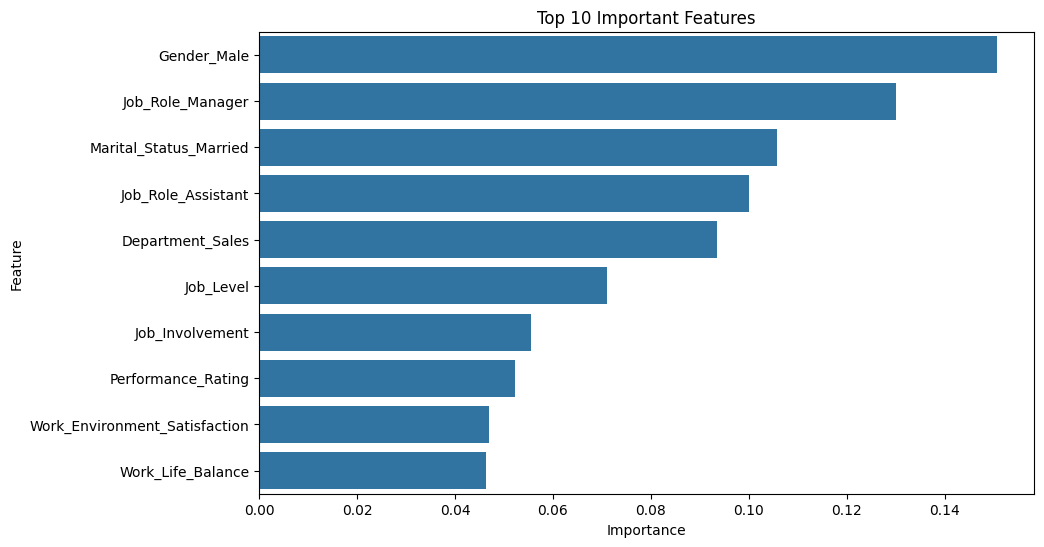

In [64]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title("Top 10 Important Features")
plt.show()

# k-NN

In [53]:

cv_knn = KNeighborsClassifier(n_neighbors=27)

knn_cv_score = cross_val_score(cv_knn, X, y, cv=k_fold)
knn_cv_mean_score = knn_cv_score.mean()
knn_cv_std_deviation= knn_cv_score.std()

cv_knn.fit(X_train_selected, y_train_smote)

y_pred_cv_knn = cv_knn.predict(X_test_selected)

acc_cv_knn = accuracy_score(y_test, y_pred_cv_knn)

y_prob_cv_knn = cv_knn.predict_proba(X_test_selected)[:,1]

knn_acc = accuracy_score(y_test, y_pred_cv_knn)
knn_prec = precision_score(y_test, y_pred_cv_knn)
knn_recall = recall_score(y_test, y_pred_cv_knn)
knn_f1 = f1_score(y_test, y_pred_cv_knn)
knn_roc = roc_auc_score(y_test, y_prob_cv_knn)
knn_conf_matrix = confusion_matrix(y_test, y_pred_cv_knn)

print("KNN Decision Tree CV Scores:", knn_cv_score)
print("KNN Mean CV F1 Score:", knn_cv_mean_score)
print("KNN Std Dev:", knn_cv_std_deviation)
print("KNN Accuracy:", knn_acc)
print("KNN Precision:", knn_prec)
print("KNN Recall:", knn_recall)
print("KNN F1 Score:", knn_f1)
print("KNN ROC AUC:", knn_roc)
print("KNN Confusion Matrix:\n", knn_conf_matrix)

KNN Decision Tree CV Scores: [0.8025 0.8    0.7965 0.7915 0.8095]
KNN Mean CV F1 Score: 0.8
KNN Std Dev: 0.006016643582596535
KNN Accuracy: 0.3985
KNN Precision: 0.20310192023633677
KNN Recall: 0.6892230576441103
KNN F1 Score: 0.3137478608100399
KNN ROC AUC: 0.4995170624875743
KNN Confusion Matrix:
 [[ 522 1079]
 [ 124  275]]


# XGBoost

In [54]:
scale_weight = sum(y_train == 0) / sum(y_train == 1)

print(scale_weight)

4.006257822277847


In [55]:
xgb = XGBClassifier(
     n_estimators=35,
    learning_rate=5,
    max_depth=5,
    scale_pos_weight=scale_weight,
     sub_sample=0.8,
     random_state=17
)

xgb_cv_scores = cross_val_score(xgb, X_train_selected, y_train_smote, cv=k_fold, scoring='f1')
xgb_cv_mean_score = xgb_cv_scores.mean()
xgb_cv_std_deviation = xgb_cv_scores.std()



xgb.fit(X_train_selected, y_train_smote)

y_pred_xgb = xgb.predict(X_test_selected)
y_prob_xgb = xgb.predict_proba(X_test_selected)[:,1]

xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_prec = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_roc = roc_auc_score(y_test, y_prob_xgb)
xgb_conf_matrix = confusion_matrix(y_test, y_pred_xgb)

print("XGB CV Scores:", xgb_cv_scores)
print("XGB Mean CV F1 Score:", xgb_cv_mean_score)
print("XGB Std Dev:", xgb_cv_std_deviation)
print('XGB Accuracy:', xgb_acc)
print('XGB Precision:', xgb_prec)
print('XGB Recall:', xgb_recall)
print('XGB F1 Score:', xgb_f1)
print('XGB ROC AUC:',  xgb_roc )
print('XGB Confusion Matrix:\n',xgb_conf_matrix)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:19:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "sub_sample" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:19:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "sub_sample" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:19:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "sub_sample" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:19:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "sub_sample" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:19:46]

XGB CV Scores: [0.62509564 0.66475495 0.48298573 0.67686722 0.59256265]
XGB Mean CV F1 Score: 0.6084532386808467
XGB Std Dev: 0.06945780281260377
XGB Accuracy: 0.532
XGB Precision: 0.18887601390498263
XGB Recall: 0.40852130325814534
XGB F1 Score: 0.2583201267828843
XGB ROC AUC: 0.4875508571553806
XGB Confusion Matrix:
 [[901 700]
 [236 163]]


# SVM

In [56]:
svm_model = SVC(
    kernel = 'rbf',
    probability=True,
    class_weight='balanced',
    random_state=17
)

svm_cv_scores = cross_val_score(svm_model, X_train_selected, y_train_smote, cv=k_fold, scoring='f1')
svm_cv_mean_score = svm_cv_scores.mean()
svm_cv_std_deviation = svm_cv_scores.std()

svm_model.fit(X_train_selected, y_train_smote)

y_pred_svm = svm_model.predict(X_test_selected)
y_prob_svm = svm_model.predict_proba(X_test_selected)[:,1]

svm_acc = accuracy_score(y_test, y_pred_svm)
svm_prec = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)
svm_roc = roc_auc_score(y_test, y_prob_svm)
svm_conf_matrix = confusion_matrix(y_test, y_pred_svm)

print("SVM CV Scores:", svm_cv_scores)
print("SVM Mean CV F1 Score:", svm_cv_mean_score)
print("SVM Std Dev:", svm_cv_std_deviation)
print('SVM Accuracy:', svm_acc)
print('SVM Precision:', svm_prec)
print('SVM Recall:', svm_recall)
print('SVM F1 Score:', svm_f1)
print('SVM ROC AUC:', svm_roc)
print('SVM Confusion Matrix:\n',svm_conf_matrix)


SVM CV Scores: [0.72993827 0.73249816 0.7324263  0.73223635 0.7303578 ]
SVM Mean CV F1 Score: 0.7314913769494531
SVM Std Dev: 0.001108134477459066
SVM Accuracy: 0.634
SVM Precision: 0.21243523316062177
SVM Recall: 0.3082706766917293
SVM F1 Score: 0.25153374233128833
SVM ROC AUC: 0.5053882363622987
SVM Confusion Matrix:
 [[1145  456]
 [ 276  123]]


# Gradient Boosting Classifier

In [57]:
gbc = GradientBoostingClassifier(
    n_estimators=75,
    learning_rate=5,
    max_depth=5,
    subsample=0.8,
     random_state=17
)

gbc_cv_scores = cross_val_score(gbc, X_train_selected, y_train_smote, cv=k_fold, scoring='f1')
gbc_cv_mean_score = gbc_cv_scores.mean()
gbc_cv_std_deviation = gbc_cv_scores.std()

gbc.fit(X_train_selected, y_train_smote)

y_pred_gbc = gbc.predict(X_test_selected)
y_prob_gbc = gbc.predict_proba(X_test_selected)[:,1]

gbc_acc = accuracy_score(y_test, y_pred_gbc)
gbc_prec = precision_score(y_test, y_pred_gbc)
gbc_recall = recall_score(y_test, y_pred_gbc)
gbc_f1 = f1_score(y_test, y_pred_gbc)
gbc_roc = roc_auc_score(y_test, y_prob_gbc)
gbc_conf_matrix = confusion_matrix(y_test, y_pred_gbc)

print("GBC CV Scores:", gbc_cv_scores)
print("GBC Mean CV F1 Score:", gbc_cv_mean_score)
print("GBC Std Dev:", gbc_cv_std_deviation)
print('GBC Accuracy:', gbc_acc)
print('GBC Precision:', gbc_prec)
print('GBC Recall:', gbc_recall)
print('GBC F1 Score:', gbc_f1)
print('GBC ROC AUC:', gbc_roc)
print('GBC Confusion Matrix:\n',gbc_conf_matrix)

GBC CV Scores: [0.68106312 0.6416316  0.63574993 0.64236453 0.64183381]
GBC Mean CV F1 Score: 0.6485285976877924
GBC Std Dev: 0.01644490361701578
GBC Accuracy: 0.4675
GBC Precision: 0.1944954128440367
GBC Recall: 0.531328320802005
GBC F1 Score: 0.2847548690396239
GBC ROC AUC: 0.48944503670168554
GBC Confusion Matrix:
 [[723 878]
 [187 212]]


# 6. Model Evaluation



In [59]:
model_scores = pd.DataFrame({

  'Model' : ['Logistic Regression', 'Decision Tree', 'Random Forest', 'KNN', 'XGBoost', 'SVM', 'GBC'],
  'CV Mean F1': [log_cv_mean_score,dt_cv_mean_score,rf_cv_mean_score,knn_cv_mean_score,xgb_cv_mean_score,svm_cv_mean_score,gbc_cv_mean_score],
  'Accuracy' : [log_acc, dt_acc, rf_acc, knn_acc, xgb_acc, svm_acc, gbc_acc],
  'Precision' : [log_prec, dt_prec, rf_prec, knn_prec, xgb_prec, svm_prec, gbc_prec],
  'Recall' : [log_recall, dt_recall, rf_recall, knn_recall, xgb_recall, svm_recall, gbc_recall],
  'F1-Score' : [log_f1, dt_f1, rf_f1, knn_f1, xgb_f1, svm_f1, gbc_f1],
  'ROC AUC' : [log_roc, dt_roc, rf_roc, knn_roc, xgb_roc, svm_roc, gbc_roc]

})


In [60]:
model_scores

,Model,CV Mean F1,Accuracy,Precision,Recall,F1-Score,ROC AUC
0,Logistic Regression,0.542337,0.4955,0.197421,0.498747,0.282871,0.516339
1,Decision Tree,0.675666,0.3590,0.206645,0.779449,0.326681,0.516832
2,Random Forest,0.834536,0.8010,0.666667,0.005013,0.009950,0.514364
3,KNN,0.800000,0.3985,0.203102,0.689223,0.313748,0.499517
4,XGBoost,0.608453,0.5320,0.188876,0.408521,0.258320,0.487551
5,SVM,0.731491,0.6340,0.212435,0.308271,0.251534,0.505388
6,GBC,0.648529,0.4675,0.194495,0.531328,0.284755,0.489445


# Which Model Performs Best?

**Decision Tree Classifier**

The Decision Tree Classifier performed best for the employee attrition prediction problem.

The model achieved:

- the highest Recall (77.94%)
- the highest test-set F1-Score (0.327)

Although the overall accuracy was relatively low (35.90%), the model was most effective at identifying employees who were actually likely to leave the organization.

# Why It Performed Best

In employee attrition prediction, Recall is one of the most important metrics because the primary business objective is to identify employees at risk of leaving before attrition occurs.

The Decision Tree model successfully identified a larger proportion of actual attrition cases compared to other models.

This is important because failing to identify high-risk employees may result in:

- increased hiring and training costs
- productivity loss
- project disruption
- reduced operational efficiency

The model also achieved the highest test-set F1-Score, indicating a better balance between Precision and Recall compared to the other evaluated models.

# Other Important Observations

**Random Forest**

Random Forest achieved:

- the highest Accuracy (80.10%)
- the highest Cross-Validation F1 Score (0.835)

However, its Recall was extremely low (0.50%), meaning the model failed to identify most employees who actually left the organization.

This indicates that the model heavily favored the majority class (“employees staying”) and may have overfitted the training data.

**KNN**

KNN achieved relatively high Recall (68.92%), but:

- Accuracy remained low
- ROC-AUC was close to 0.50

This suggests weak class-separation capability and unstable prediction performance.

**Overall Model Performance**

Most models produced:

- ROC-AUC scores near 0.50
- low Precision values
- moderate-to-low F1-Scores

This indicates that employee attrition is difficult to predict accurately using the available dataset variables alone.

Additional organizational and behavioral variables may improve prediction performance in future implementations. Humans keep hoping a spreadsheet will reveal the full emotional mechanics of why people quit jobs. The spreadsheet, meanwhile, is fighting for its life at ROC-AUC 0.51.

# Why certain metrics are important in business scenarios

**Accuracy**

Accuracy measures the percentage of overall correct predictions.

However, in imbalanced datasets, high accuracy alone may be misleading because models can predict the majority class excessively while failing to identify actual attrition cases.

**Precision**

Precision measures how many employees predicted as “likely to leave” actually resigned.

High Precision is important because:

- excessive false alarms may waste HR resources
- unnecessary employee interventions can reduce operational efficiency

**Recall**

Recall measures how many actual attrition cases were correctly identified.

Recall is especially important in attrition prediction because:

- missing high-risk employees may lead to:
- - increased recruitment costs
- - productivity loss
- - project delays

**F1-Score**

F1-Score balances Precision and Recall.

It is particularly useful when:

- class imbalance exists
- both false positives and false negatives matter

**ROC-AUC**

ROC-AUC measures how effectively a model separates attrition and non-attrition cases.

ROC-AUC scores near 0.50 indicate weak classification capability and suggest that the current dataset may not fully capture the true drivers of employee attrition.

#7. Business Insights and Recommendations

**Key Factors Influencing Attrition**

The Random Forest feature importance analysis identified several variables that contributed most strongly to attrition prediction, including:

- job role
- department
- job level
- job involvement
- work environment satisfaction
- work-life balance
- performance rating

The feature importance table above summarizes the relative contribution of these variables within the model.

Additionally, exploratory analysis showed slightly higher attrition levels in Sales and Marketing departments.

However, because overall model ROC-AUC scores remained relatively weak, these findings should be interpreted as indicators of potential influence rather than definitive causal factors.

**High-Risk Employee Profiles**

Based on feature importance analysis and exploratory analysis, employees potentially at higher attrition risk include:

- employees in Sales-related roles
- managerial and assistant-level employees
- employees with lower work-life balance
- employees with lower work environment satisfaction
- employees with lower job involvement

These variables showed measurable influence within the predictive models and may contribute to attrition behavior

**Departments with Higher Attrition Risk**

Exploratory analysis showed slightly higher attrition levels in:

- Sales
- Marketing

This suggests that departments involving:

- higher workload pressure
- customer-facing responsibilities
- performance-based targets

may experience relatively higher attrition levels.

However, department-wise differences were not extremely large, indicating that attrition may also be influenced by broader organizational factors.

**HR Intervention Strategies**

**Improve Employee Experience**

Organizations should strengthen:

- work-life balance initiatives
- employee engagement programs
- workplace satisfaction monitoring
- employee involvement activities

because workplace experience variables showed measurable importance within the predictive models.

**Strengthen Career Development**

Organizations should:

- improve career growth opportunities
- strengthen promotion transparency
- provide employee development and training programs

because job level and performance-related variables contributed to attrition prediction.

**Monitor High-Influence Roles and Departments**

HR teams should pay closer attention to:

- Sales department employees
- managerial roles
- assistant-level employees

because these variables showed relatively higher predictive importance.

# Actionable Recommendations for Management

**1. Use Predictive Models as HR Support Tools**

The models should be used as:

- early-warning systems
- workforce trend analysis tools
- supplementary HR decision-support systems

rather than fully automated employee decision systems.

**2. Improve Workplace Satisfaction**

Management should:

- conduct regular employee feedback sessions
- improve communication between managers and employees
- strengthen employee recognition initiatives

to improve employee experience and retention.


**3. Strengthen Work-Life Balance Policies**

Organizations should:

- monitor overtime patterns
- encourage flexible work arrangements
- reduce excessive workload pressure

to support employee well-being.


**4. Enhance Career Growth Opportunities**

Management should:

- provide clear promotion pathways
- offer training and skill development programs
- improve internal mobility opportunities

to improve long-term employee retention and engagement.